/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_7556/2457854183.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Segment', data=rfm, order=rfm['Segment'].value_counts().index, palette='viridis')


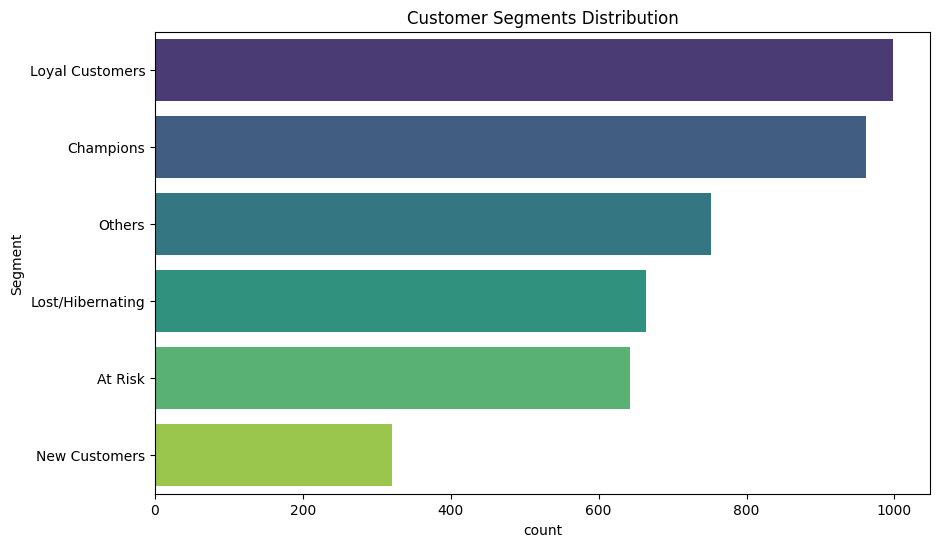

            Recency  Frequency  Monetary  R  F  M           Segment
CustomerID                                                         
12346.0         326          1  77183.60  1  1  5  Lost/Hibernating
12347.0           2          7   4310.00  5  5  5         Champions
12348.0          75          4   1797.24  2  4  4           At Risk
12349.0          19          1   1757.55  4  1  4     New Customers
12350.0         310          1    334.40  1  1  2  Lost/Hibernating


In [3]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
df = pd.read_csv('/Users/apple/Downloads/UCI.csv', encoding='ISO-8859-1')

# 2. DATA CLEANING
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove rows without CustomerID and remove cancellations (Invoice starting with 'C')
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].str.contains('C', na=False)]
df = df[df['Quantity'] > 0]

# Calculate total price per line item
df['TotalSum'] = df['Quantity'] * df['UnitPrice']

# 3. CALCULATE RFM METRICS
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                 # Frequency
    'TotalSum': 'sum'                                       # Monetary
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

# 4. SCORING (Assigning 1-5)
# Recency: Lower days = Higher score (5)
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency & Monetary: Higher value = Higher score (5)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 5. SEGMENTATION LOGIC
def segment_customer(df):
    r, f, m = df['R'], df['F'], df['M']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 1:
        return 'Lost/Hibernating'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# 6. VISUALIZATION
plt.figure(figsize=(10, 6))
sns.countplot(y='Segment', data=rfm, order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Customer Segments Distribution')
plt.show()

# Display the first few rows of the final result
print(rfm.head())

/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_7556/2506133531.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rfm_heatmap = rfm.pivot_table(index='R', columns='F', values='Monetary', aggfunc='mean')


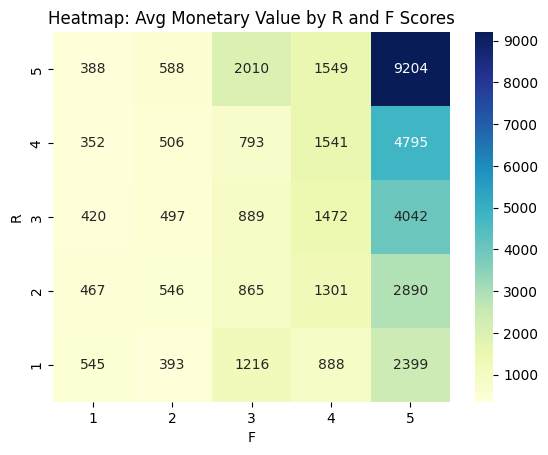

In [4]:
# Bonus: Heatmap of Recency vs Frequency
rfm_heatmap = rfm.pivot_table(index='R', columns='F', values='Monetary', aggfunc='mean')
sns.heatmap(rfm_heatmap, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Avg Monetary Value by R and F Scores')
plt.show()

# **Marketing Ideas Suggestions**

# Champions (High R, High F, High M)

Behavior: Your best customers. They shop often, spend the most, and bought recently.

Strategy: Do not offer discounts. Instead, give them VIP rewards, early access to new products, and personalized "thank you" notes to build 
brand advocacy.

# Loyal Customers (High F, Moderate R)

Behavior: Shop regularly and are responsive to your brand.

Strategy: Focus on Upselling. Suggest higher-value items based on their past purchase history or invite them into a "refer-a-friend" loyalty program.

# New Customers (High R, Low F)

Behavior: Just made their first purchase.

Strategy: Create a Welcome Sequence. Send an email explaining your brand story and offer a "second-purchase discount" to turn them into repeat buyers.

# At Risk (Low R, High F, High M)

Behavior: High-value customers who haven't shopped in a long time. They are likely switching to a competitor.

Strategy: Send Win-Back Campaigns. Use "We miss you" messaging combined with a significant, time-limited discount (e.g., 20% off) to bring them back.

# Lost / Hibernating (Low R, Low F, Low M)

Behavior: Haven't bought in a long time and spent very little.

Strategy: Use Low-Cost Automation. Don't spend ad budget here. Set up an automated email to check in once every 6 months, but otherwise, focus resources on higher-value segments.